In [5]:
from pathlib import Path
import numpy as np
import laspy
import matplotlib.pyplot as plt

gridnet_root = Path("data/gridnet_hd/t1z5b")
las_path = gridnet_root / "lidar" / "t1z5b.las"

print("Opening:", las_path)
las = laspy.read(las_path)
print(f"Loaded {len(las.points):,} points")

Opening: data\gridnet_hd\t1z5b\lidar\t1z5b.las
Loaded 59,624,089 points


In [6]:
# Pull coordinates and labels as numpy arrays
x = np.array(las.x)
y = np.array(las.y)
z = np.array(las.z)
gt = np.array(las.ground_truth)

# Filter to pylon points (classes 0, 1, 2, 3, 4 in original IDs all map to "Pylon")
pylon_mask = np.isin(gt, [0, 1, 2, 3, 4])

x_pylon = x[pylon_mask]
y_pylon = y[pylon_mask]
z_pylon = z[pylon_mask]

print(f"Pylon points: {len(x_pylon):,}")

# Stack into a single (N, 3) array — DBSCAN wants this shape
pylon_xyz = np.column_stack([x_pylon, y_pylon, z_pylon])
print(f"Shape: {pylon_xyz.shape}")

Pylon points: 337,033
Shape: (337033, 3)


In [7]:
import sklearn
print("sklearn version:", sklearn.__version__)

sklearn version: 1.7.2


In [8]:
from sklearn.cluster import DBSCAN

# Downsample: take every 20th pylon point
# This is ~17k points instead of 337k — much faster, same cluster structure
downsample_factor = 20
pylon_xyz_ds = pylon_xyz[::downsample_factor]
print(f"Downsampled from {len(pylon_xyz):,} to {len(pylon_xyz_ds):,} points")

# Cluster
clustering = DBSCAN(eps=30, min_samples=20, n_jobs=-1)
labels_ds = clustering.fit_predict(pylon_xyz_ds)

# Inspect
unique_labels, counts = np.unique(labels_ds, return_counts=True)
print(f"\nNumber of clusters: {len(unique_labels[unique_labels >= 0])}")
print(f"Noise points (label = -1): {(labels_ds == -1).sum():,}")
print()
print("Cluster sizes:")
for lbl, cnt in zip(unique_labels, counts):
    name = f"Pylon {lbl}" if lbl >= 0 else "Noise"
    print(f"  {name}: {cnt:,} points")

Downsampled from 337,033 to 16,852 points

Number of clusters: 3
Noise points (label = -1): 0

Cluster sizes:
  Pylon 0: 4,776 points
  Pylon 1: 5,924 points
  Pylon 2: 6,152 points


In [9]:
from sklearn.neighbors import NearestNeighbors

# Propagate downsampled cluster labels back to full pylon points
# For each full-resolution point, find its nearest downsampled point and inherit its label
nn = NearestNeighbors(n_neighbors=1, n_jobs=-1)
nn.fit(pylon_xyz_ds)
_, nearest_idx = nn.kneighbors(pylon_xyz)
labels_full = labels_ds[nearest_idx.flatten()]

print(f"Full-resolution labels assigned: {len(labels_full):,}")
print(f"Unique labels: {np.unique(labels_full)}")

# Compute centroid for each pylon cluster on full point set
print("\nPylon centroids (UTM coordinates, metres):")
print(f"{'Pylon':>6} | {'X (UTM)':>12} | {'Y (UTM)':>14} | {'Z (m alt)':>10} | {'# points':>10}")
print("-" * 70)

pylon_centroids = []
for lbl in sorted(np.unique(labels_full)):
    if lbl < 0:  # skip noise
        continue
    mask = labels_full == lbl
    cx = pylon_xyz[mask, 0].mean()
    cy = pylon_xyz[mask, 1].mean()
    cz = pylon_xyz[mask, 2].mean()
    n = mask.sum()
    pylon_centroids.append({"pylon_id": int(lbl), "x": cx, "y": cy, "z": cz, "n_points": int(n)})
    print(f"{int(lbl):>6} | {cx:>12.2f} | {cy:>14.2f} | {cz:>10.2f} | {n:>10,}")

Full-resolution labels assigned: 337,033
Unique labels: [0 1 2]

Pylon centroids (UTM coordinates, metres):
 Pylon |      X (UTM) |        Y (UTM) |  Z (m alt) |   # points
----------------------------------------------------------------------
     0 |    383152.68 |     5099730.82 |    1905.13 |     95,499
     1 |    383172.62 |     5100036.10 |    1895.59 |    118,493
     2 |    383188.49 |     5100278.60 |    1888.06 |    123,041


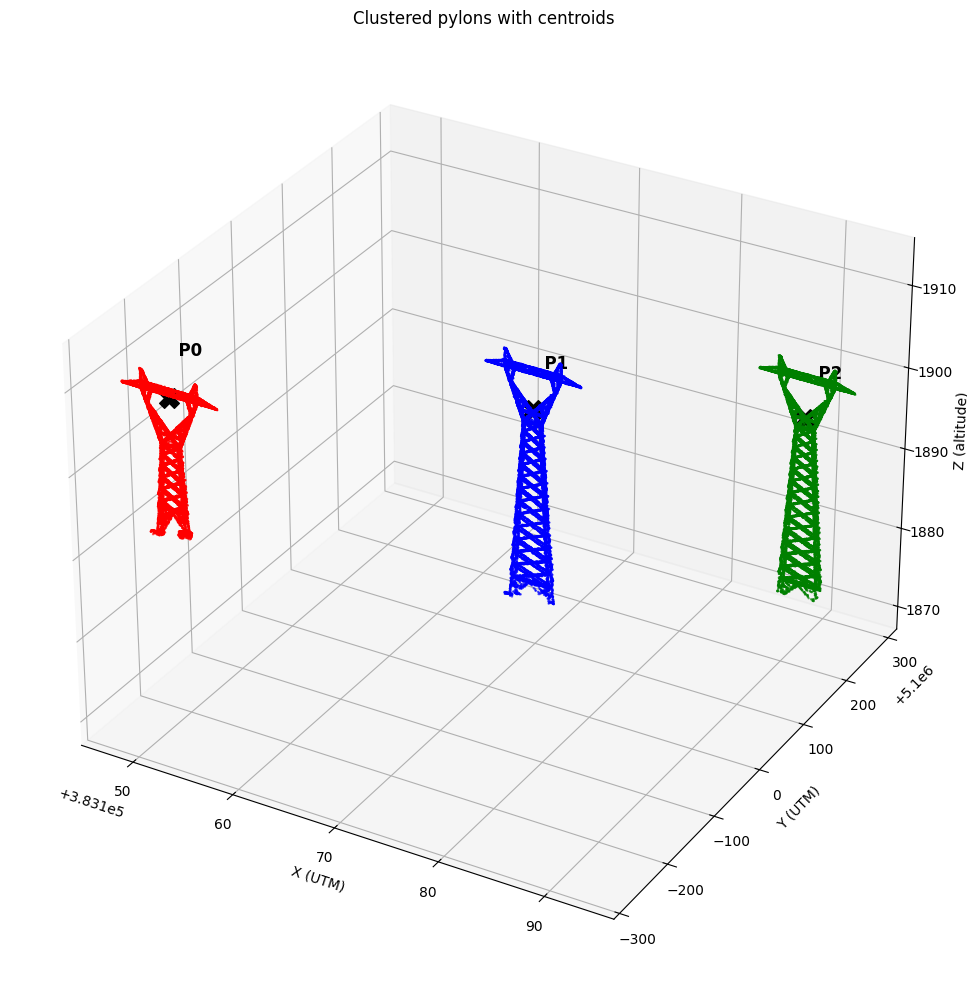

In [11]:
# Downsample for plotting (full set is too dense to render)
plot_every = 5
xs = pylon_xyz[::plot_every, 0]
ys = pylon_xyz[::plot_every, 1]
zs = pylon_xyz[::plot_every, 2]
ls = labels_full[::plot_every]

cluster_colours = {0: "red", 1: "blue", 2: "green"}
point_colours = np.array([cluster_colours.get(l, "grey") for l in ls])

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(xs, ys, zs, c=point_colours, s=0.5, alpha=0.6)

# Overlay centroids as big black dots with labels
for c in pylon_centroids:
    ax.scatter(c["x"], c["y"], c["z"] + 5, c="black", s=200, marker="X")
    ax.text(c["x"], c["y"], c["z"] + 10, f"  P{c['pylon_id']}", fontsize=12, weight="bold")

ax.set_xlabel("X (UTM)")
ax.set_ylabel("Y (UTM)")
ax.set_zlabel("Z (altitude)")
ax.set_title("Clustered pylons with centroids")
plt.tight_layout()
plt.savefig("figures/pylon_clusters_3d.png", dpi=200, bbox_inches="tight")
plt.show()

In [12]:
# Filter to insulator points
insulator_mask = np.isin(gt, [8, 9, 10, 11])
x_ins = x[insulator_mask]
y_ins = y[insulator_mask]
z_ins = z[insulator_mask]

insulator_xyz = np.column_stack([x_ins, y_ins, z_ins])
print(f"Insulator points: {len(insulator_xyz):,}")

# Insulators are smaller and closer together than pylons,
# so eps and min_samples need to be tighter
# An insulator string is ~30 cm — and multiple insulators sit on the same pylon crossarm,
# separated by maybe 1–3 metres of empty space
clustering_ins = DBSCAN(eps=0.5, min_samples=20, n_jobs=-1)
labels_ins = clustering_ins.fit_predict(insulator_xyz)

unique_labels, counts = np.unique(labels_ins, return_counts=True)
print(f"\nNumber of insulator clusters: {len(unique_labels[unique_labels >= 0])}")
print(f"Noise points: {(labels_ins == -1).sum():,}")
print()
print("Cluster sizes:")
for lbl, cnt in zip(unique_labels, counts):
    name = f"Insulator {lbl}" if lbl >= 0 else "Noise"
    print(f"  {name}: {cnt:,} points")

Insulator points: 8,790

Number of insulator clusters: 9
Noise points: 0

Cluster sizes:
  Insulator 0: 851 points
  Insulator 1: 1,091 points
  Insulator 2: 1,091 points
  Insulator 3: 846 points
  Insulator 4: 1,017 points
  Insulator 5: 980 points
  Insulator 6: 1,028 points
  Insulator 7: 845 points
  Insulator 8: 1,041 points


In [13]:
# Compute centroid for each insulator
insulator_centroids = []
for lbl in sorted(np.unique(labels_ins)):
    if lbl < 0:
        continue
    mask = labels_ins == lbl
    cx = insulator_xyz[mask, 0].mean()
    cy = insulator_xyz[mask, 1].mean()
    cz = insulator_xyz[mask, 2].mean()
    n = mask.sum()
    insulator_centroids.append({
        "insulator_id": int(lbl),
        "x": cx,
        "y": cy,
        "z": cz,
        "n_points": int(n),
    })

# For each insulator, find its nearest pylon
pylon_coords = np.array([[p["x"], p["y"], p["z"]] for p in pylon_centroids])

print(f"{'Ins ID':>6} | {'X':>10} | {'Y':>12} | {'Z':>10} | {'Parent pylon':>12} | {'Dist to pylon (m)':>17}")
print("-" * 85)

for ins in insulator_centroids:
    ins_xyz = np.array([ins["x"], ins["y"], ins["z"]])
    distances = np.linalg.norm(pylon_coords - ins_xyz, axis=1)
    nearest_idx = int(np.argmin(distances))
    ins["parent_pylon"] = pylon_centroids[nearest_idx]["pylon_id"]
    ins["dist_to_pylon"] = float(distances[nearest_idx])
    
    print(f"{ins['insulator_id']:>6} | {ins['x']:>10.2f} | {ins['y']:>12.2f} | "
          f"{ins['z']:>10.2f} | {ins['parent_pylon']:>12} | {ins['dist_to_pylon']:>17.2f}")

Ins ID |          X |            Y |          Z | Parent pylon | Dist to pylon (m)
-------------------------------------------------------------------------------------
     0 |  383152.70 |   5099730.85 |    1909.34 |            0 |              4.21
     1 |  383157.18 |   5099730.54 |    1909.47 |            0 |              6.26
     2 |  383148.17 |   5099731.17 |    1909.49 |            0 |              6.29
     3 |  383172.67 |   5100036.16 |    1903.92 |            1 |              8.33
     4 |  383168.14 |   5100036.45 |    1904.03 |            1 |              9.56
     5 |  383177.15 |   5100035.84 |    1903.99 |            1 |              9.55
     6 |  383184.01 |   5100278.89 |    1896.86 |            2 |              9.87
     7 |  383188.49 |   5100278.62 |    1896.73 |            2 |              8.67
     8 |  383193.02 |   5100278.34 |    1896.80 |            2 |              9.84


In [14]:
import csv

# Save pylons
with open("pylons.csv", "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["pylon_id", "x", "y", "z", "n_points"])
    writer.writeheader()
    writer.writerows(pylon_centroids)

# Save insulators
with open("insulators.csv", "w", newline="") as f:
    writer = csv.DictWriter(
        f, 
        fieldnames=["insulator_id", "parent_pylon", "x", "y", "z", "n_points", "dist_to_pylon"]
    )
    writer.writeheader()
    writer.writerows(insulator_centroids)

print("Wrote pylons.csv (3 rows) and insulators.csv (9 rows)")
print()
print("--- pylons.csv ---")
print(Path("pylons.csv").read_text())
print("--- insulators.csv ---")
print(Path("insulators.csv").read_text())

Wrote pylons.csv (3 rows) and insulators.csv (9 rows)

--- pylons.csv ---
pylon_id,x,y,z,n_points
0,383152.68148338783,5099730.820778781,1905.1276075543976,95499
1,383172.6167350823,5100036.096979312,1895.5897744057227,118493
2,383188.4852405629,5100278.600441276,1888.062049156962,123041

--- insulators.csv ---
insulator_id,parent_pylon,x,y,z,n_points,dist_to_pylon
0,0,383152.69718395534,5099730.845019088,1909.3390290061366,851,4.211520478935769
1,0,383157.1821821938,5099730.53501047,1909.4720239305313,1091,6.261941146202894
2,0,383148.1683700948,5099731.168650434,1909.4893916665537,1091,6.286045412208316
3,1,383172.6671806905,5100036.159446577,1903.922187387182,846,8.332799830319326
4,1,383168.1425982128,5100036.453229719,1904.0282981112557,1017,9.55790235398473
5,1,383177.1472608541,5100035.835959871,1903.9884041985872,980,9.546244147026945
6,2,383184.00854151987,5100278.893082578,1896.855124007211,1028,9.87140509629544
7,2,383188.49416026956,5100278.621955523,1896.7299753119794,845,